# 03 - Fraud Label Simulation

---
The goal is to Assign a binary `is_fraud` label to every transaction using
fully deterministic rule combinations.

**Why deterministic?**
Previous versions used a random acceptance gate — 30% of qualifying
transactions were labelled fraud, 70% labelled legitimate even though
they had identical features. This is label noise. The model sees the
same feature combination mapping to both classes and cannot learn a
clean boundary. Removing the random gate gives consistent, learnable labels.

**Input:** `data/processed/parsed_logs.csv`

**Output:** `data/processed/labelled_logs.csv`


## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette('muted')

# Fixed seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

INPUT_PATH  = Path('../data/processed/parsed_logs.csv')
OUTPUT_PATH = Path('../data/processed/labelled_logs.csv')

print('Setup complete.')

Setup complete.


## 2. Load and Sort Data

Sort by `user_id + timestamp` — required for the device switch calculation.

In [2]:
df = pd.read_csv(INPUT_PATH, parse_dates=['timestamp'])
df = df.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

print('Shape :', df.shape)
print()
df.head()


Shape : (7774, 8)



,timestamp,user_id,txn_type,amount,currency,location,device,log_format
0,2025-06-01 12:03:31,user1000,cashout,2981.2100,$,London,Samsung Galaxy S10,dash_equals
1,2025-06-01 19:19:50,user1000,debit,1267.6700,€,Manchester,Xiaomi Mi 11,dmy_triple_colon
2,2025-06-02 19:52:44,user1000,refund,3610.6800,$,Cardiff,Huawei P30,pipe_bar
3,2025-06-03 10:11:53,user1000,cashout,4659.0600,£,Birmingham,Nokia 3310,dash_equals
4,2025-06-03 21:23:30,user1000,cashout,4063.9700,£,Liverpool,NaN,pipe_bar


## 3. Compute Signal Flags

Five binary signals derived from the transaction data.
Each is 1 if the condition is met, 0 otherwise.

Note: `sig_device_switch` (72.7% activation) and `sig_high_velocity`
(0.01% activation) are excluded from the fraud rules — device switch
is too common to be a useful discriminator, and velocity never fires
in this dataset due to 86 users spread over 59 days.

In [3]:
RISKY_TYPES = {'cashout', 'withdrawal', 'transfer'}

# Night transaction: 00:00 to 05:59
df['sig_night'] = df['timestamp'].dt.hour.between(0, 5).astype(int)

# High amount: >= 4,000
df['sig_high_amount'] = (df['amount'] >= 4000).astype(int)

# Risky transaction type: cashout, withdrawal, transfer
df['sig_risky_type'] = df['txn_type'].isin(RISKY_TYPES).astype(int)

# Missing location: location was None in the raw log
df['sig_missing_loc'] = df['location'].isna().astype(int)

# Missing device: device was None in the raw log
df['sig_missing_device'] = df['device'].isna().astype(int)

# Device switch: user changed device from previous transaction
df['prev_device'] = df.groupby('user_id')['device'].shift(1)
df['sig_device_switch'] = (
    (df['device'] != df['prev_device']) & df['prev_device'].notna()
).astype(int)
df.drop(columns=['prev_device'], inplace=True)

print('Signal activation rates:')
signals = ['sig_night','sig_high_amount','sig_risky_type',
           'sig_missing_loc','sig_missing_device','sig_device_switch']
for s in signals:
    n = df[s].sum()
    print('  {:<25}: {:>5}  ({:.1f}%)'.format(s, n, n/len(df)*100))


Signal activation rates:
  sig_night                :  1978  (25.4%)
  sig_high_amount          :  1523  (19.6%)
  sig_risky_type           :  2944  (37.9%)
  sig_missing_loc          :   968  (12.5%)
  sig_missing_device       :  1081  (13.9%)
  sig_device_switch        :  5649  (72.7%)


## 4. Deterministic Fraud Rules

Each rule is a specific combination of signals that must ALL fire together.
A transaction matching any rule is always labelled fraud — no randomness.

**Why these three rules?**

| Rule | Signals | Business meaning |
|------|---------|------------------|
| A | Night + High amount + Risky type | Late-night large cashout/withdrawal — classic card fraud |
| B | Night + High amount + Missing location | Large transaction at night with no location — suspicious origin |
| C | High amount + Device switch + Missing location | Large transaction on a new device with no location — account takeover |

These three were chosen because:
- Each combination is rare enough to give a 3-6% fraud rate
- Each has a clear real-world fraud narrative
- They do not overlap heavily — each captures a distinct fraud pattern
- None relies on `sig_device_switch` alone (too common at 72.7%)
- None relies on velocity (never fires in this dataset)

In [4]:
# Rule A: Night + High amount + Risky transaction type
# Narrative: large cashout or withdrawal in the early hours
rule_a = (
    (df['sig_night']       == 1) &
    (df['sig_high_amount'] == 1) &
    (df['sig_risky_type']  == 1)
)

# Rule B: Night + High amount + Missing location
# Narrative: large transaction at night with no traceable location
rule_b = (
    (df['sig_night']       == 1) &
    (df['sig_high_amount'] == 1) &
    (df['sig_missing_loc'] == 1)
)

# Rule C: High amount + Device switch + Missing location
# Narrative: large transaction on a new device with no location — account takeover
rule_c = (
    (df['sig_high_amount']    == 1) &
    (df['sig_device_switch']  == 1) &
    (df['sig_missing_loc']    == 1)
)

print('Rule activation counts:')
print('  Rule A (Night + High amt + Risky)      : {:>4}  ({:.2f}%)'.format(
    rule_a.sum(), rule_a.mean()*100))
print('  Rule B (Night + High amt + Missing loc) : {:>4}  ({:.2f}%)'.format(
    rule_b.sum(), rule_b.mean()*100))
print('  Rule C (High amt + Dev switch + No loc) : {:>4}  ({:.2f}%)'.format(
    rule_c.sum(), rule_c.mean()*100))
print()
print('  Overlap (A and B)  :', (rule_a & rule_b).sum())
print('  Overlap (A and C)  :', (rule_a & rule_c).sum())
print('  Overlap (B and C)  :', (rule_b & rule_c).sum())
print('  Overlap (all three):', (rule_a & rule_b & rule_c).sum())


Rule activation counts:
  Rule A (Night + High amt + Risky)      :  136  (1.75%)
  Rule B (Night + High amt + Missing loc) :   54  (0.69%)
  Rule C (High amt + Dev switch + No loc) :  138  (1.78%)

  Overlap (A and B)  : 21
  Overlap (A and C)  : 19
  Overlap (B and C)  : 41
  Overlap (all three): 19


## 5. Assign Fraud Labels

A transaction is fraud if it matches **any** of the three rules.
No randomness — same features always produce the same label.
This gives the model clean, consistent signal to learn from.

In [5]:
# Fraud = matches any rule — fully deterministic
df['is_fraud'] = (rule_a | rule_b | rule_c).astype(int)

fraud_n = df['is_fraud'].sum()
legit_n = (df['is_fraud'] == 0).sum()

print('Label distribution:')
print('  Legitimate : {:>5}  ({:.1f}%)'.format(legit_n, legit_n/len(df)*100))
print('  Fraud      : {:>5}  ({:.1f}%)'.format(fraud_n, fraud_n/len(df)*100))
print('  Ratio      : {:.0f}:1'.format(legit_n/fraud_n))


Label distribution:
  Legitimate :  7508  (96.6%)
  Fraud      :   266  (3.4%)
  Ratio      : 28:1


## 6. Validate Labels

With deterministic rules, separation should be near-perfect for the
defining signals. Fraud rows should have 100% activation on the
signals that define their rule.

In [6]:
validation = df.groupby('is_fraud').agg(
    count              = ('amount', 'count'),
    mean_amount        = ('amount', 'mean'),
    night_rate         = ('sig_night', 'mean'),
    high_amount_rate   = ('sig_high_amount', 'mean'),
    risky_type_rate    = ('sig_risky_type', 'mean'),
    missing_loc_rate   = ('sig_missing_loc', 'mean'),
    device_switch_rate = ('sig_device_switch', 'mean'),
).round(3)
validation.index = ['Legitimate', 'Fraud']
print('Separation check:')
print(validation.T.to_string())


Separation check:
                    Legitimate     Fraud
count                7508.0000  266.0000
mean_amount          2409.4230 4448.2000
night_rate              0.2410    0.6350
high_amount_rate        0.1670    1.0000
risky_type_rate         0.3700    0.6320
missing_loc_rate        0.1090    0.5680
device_switch_rate      0.7230    0.8310


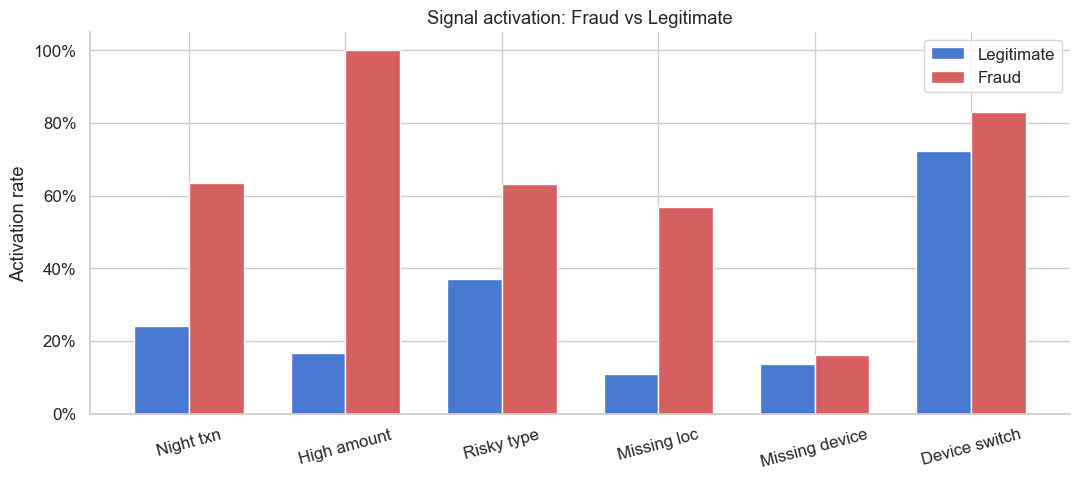

In [7]:
# Signal activation: fraud vs legitimate
signal_labels = {
    'Night txn'     : 'sig_night',
    'High amount'   : 'sig_high_amount',
    'Risky type'    : 'sig_risky_type',
    'Missing loc'   : 'sig_missing_loc',
    'Missing device': 'sig_missing_device',
    'Device switch' : 'sig_device_switch',
}

legit_rates = [df[df['is_fraud']==0][col].mean() for col in signal_labels.values()]
fraud_rates = [df[df['is_fraud']==1][col].mean() for col in signal_labels.values()]
labels      = list(signal_labels.keys())
x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, legit_rates, width, label='Legitimate', color=COLORS[0], edgecolor='white')
ax.bar(x + width/2, fraud_rates, width, label='Fraud',      color=COLORS[3], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Activation rate')
ax.set_title('Signal activation: Fraud vs Legitimate')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: '{:.0%}'.format(v)))
sns.despine()
plt.tight_layout()
plt.show()


## 7. Class Imbalance

Visualise the class distribution. SMOTE inside the modelling pipeline
will handle this imbalance during training.

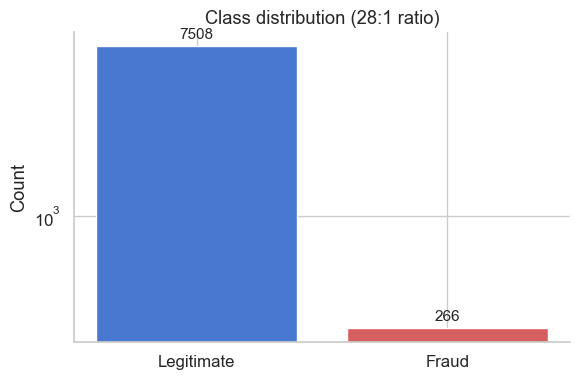

Implication for modelling:
  Accuracy of all-legit baseline : 96.6%
  We use PR-AUC as primary metric, not accuracy.


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Legitimate', 'Fraud'], [legit_n, fraud_n],
       color=[COLORS[0], COLORS[3]], edgecolor='white')
ax.bar_label(ax.containers[0], padding=3, fontsize=11)
ax.set_ylabel('Count')
ax.set_title('Class distribution ({:.0f}:1 ratio)'.format(legit_n/fraud_n))
ax.set_yscale('log')
sns.despine()
plt.tight_layout()
plt.show()

print('Implication for modelling:')
print('  Accuracy of all-legit baseline : {:.1f}%'.format(legit_n/len(df)*100))


## 8. Save Labelled Dataset

Drop signal columns before saving — they will be re-derived properly
in `04_feature_engineering.ipynb` alongside richer features.
We keep `is_fraud` as the label column.

In [9]:
signal_cols = [
    'sig_night', 'sig_high_amount', 'sig_risky_type',
    'sig_missing_loc', 'sig_missing_device', 'sig_device_switch',
]

output_df = df.drop(columns=signal_cols)

print('Output columns:', list(output_df.columns))
print('Output shape  :', output_df.shape)
print()
print('Label distribution:')
print(output_df['is_fraud'].value_counts().to_string())

output_df.to_csv(OUTPUT_PATH, index=False)

verify = pd.read_csv(OUTPUT_PATH)
print()
print('Saved to  :', OUTPUT_PATH)
print('File size : {:.1f} KB'.format(OUTPUT_PATH.stat().st_size / 1024))
print('Shape     :', verify.shape)


Output columns: ['timestamp', 'user_id', 'txn_type', 'amount', 'currency', 'location', 'device', 'log_format', 'is_fraud']
Output shape  : (7774, 9)

Label distribution:
0    7508
1     266

Saved to  : ..\data\processed\labelled_logs.csv
File size : 615.1 KB
Shape     : (7774, 9)

Next step -> 04_feature_engineering.ipynb
